# PROTECT-90 — A Fault Dataset for Power System Protection

> **A guided tour of the dataset.** This notebook loads the raw release, explains the schema, and
> visualises what the episodes and labels actually look like. It is meant to be *read* — every figure
> below is reproduced from the published data with the code in the cell above it.

**PROTECT-90** is an open transmission-level fault-waveform dataset: **9,022 electromagnetic-transient
(EMT) simulation episodes** on a fully documented **90 kV double-line** topology, sampled at **6.4 kHz**
with **48 synchronised current/voltage channels** per episode, generated under physically constrained
domain randomisation.

| | |
|---|---|
| 📦 **Dataset (Zenodo)** | https://doi.org/10.5281/zenodo.21109169 (v1.0.0; concept DOI 10.5281/zenodo.18418329) |
| 📄 **Paper** | *PROTECT-90: A Fault Dataset for Power System Protection* — accepted at IEEE PES ISGT Europe 2026 (Budapest); preprint [arXiv:2606.24298](https://arxiv.org/abs/2606.24298) |
| ⚖️ **License** | CC BY 4.0 |
| 🔬 **Protection baselines** | `protect-90-baselines` (physics-based reference methods) |

**Two distinct artifacts** (don't conflate): the **dataset** is the Zenodo release you download
(DOI `10.5281/zenodo.21109169`, CC BY 4.0); the **paper** is the IEEE PES ISGT Europe 2026
publication (Budapest, Oct 2026) that describes it (DOI to be assigned). Cite whichever you rely on —
see the final section.

Developed within the DFG project **Coordinated Power System Protection using Machine Learning
(Netzschutz-KI)**, project no. 535389056, FAU Erlangen-Nürnberg.

## 1. Getting the data

Download the release from Zenodo and extract the preprocessed archive. The expected layout is:

```
<DATA_DIR>/
├── hv_double_line_90kv_labels.csv              # per-episode metadata (9,022 rows)
└── hv_double_line_90kv_preprocessed_data/
    └── {sample_id}_sample_hv_double_line_90kv.pkl   # one pandas DataFrame per episode
```

Point the notebook at that directory with the `PROTECT90_DATA` environment variable
(default: `./data`).

In [1]:
import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Location of the extracted Zenodo release (override with PROTECT90_DATA).
DATA_DIR = Path(os.environ.get("PROTECT90_DATA", "data"))
CSV_PATH = DATA_DIR / "hv_double_line_90kv_labels.csv"
PKL_DIR  = DATA_DIR / "hv_double_line_90kv_preprocessed_data"
FIG_DIR  = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# Colour-blind-friendly palette (Wong) + a consistent figure style.
BLUE, ORANGE, GREEN, RED, PURPLE, GREY = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#999999"
PHASE_COLORS = {"L1": BLUE, "L2": ORANGE, "L3": GREEN}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.dpi": 150,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
FS = 6400.0  # sampling frequency [Hz]
print("Reading PROTECT-90 from:", DATA_DIR.resolve())

Reading PROTECT-90 from: /home/<user>/Repositories/protect90-dataset/data


## 2. Per-episode metadata

`hv_double_line_90kv_labels.csv` has one row per episode. The key scenario columns are integer-coded;
their meaning (decoded below) was confirmed against the dataset's own per-window phase/ground labels:

| code column | meaning |
|---|---|
| `sc_type` | fault category — **0 = LLL** (three-phase), **1 = LL** (line–line), **2 = SLG** (single-line-ground), **3 = LLG** (line–line-ground) |
| `fault_target` | faulted line section (`Line_1_2_a/b`, `Line_2_3_a/b`) |
| `sc_location` | fault position, % of line length from the sending bus |
| `fault_resistance` | fault resistance [Ω] |
| `phase_select` | base-phase rotation index (A/B/C group) |
| `t_evnt_start` | fault inception time [s] |

The remaining columns record the domain-randomised line parameters (per-line `length`, `xline`, `rline`,
`cline` and their zero-sequence `*0` variants), load set-points, external-grid strength, and topology
switching states.

In [2]:
SC_TYPE = {0: "LLL", 1: "LL", 2: "SLG", 3: "LLG"}

meta = pd.read_csv(CSV_PATH)
meta["fault_type"] = meta["sc_type"].map(SC_TYPE)
print(f"{len(meta):,} episodes x {meta.shape[1]} metadata columns")
meta[["sample_id", "sc_type", "fault_type", "fault_target",
      "sc_location", "fault_resistance", "phase_select", "t_evnt_start"]].head()

9,022 episodes x 50 metadata columns


,sample_id,sc_type,fault_type,fault_target,sc_location,fault_resistance,phase_select,t_evnt_start
0,0,2,SLG,Line_2_3_a,19.547918,4.051499,1,0.428642
1,1,3,LLG,Line_2_3_a,87.564951,7.549922,1,0.469852
2,2,2,SLG,Line_2_3_a,71.874684,7.639229,1,0.385552
3,3,3,LLG,Line_2_3_a,62.977103,5.064218,2,0.339056
4,4,1,LL,Line_2_3_a,75.769514,2.730902,1,0.264736


## 3. Episode structure and the 48 channels

Each episode is a pandas DataFrame of shape **(6400, 49)**: a `time_s` column (1.0 s at 6.4 kHz,
i.e. 128 samples per 50 Hz cycle) plus **48 measurement channels** — ideal three-phase voltages and
currents (no CT/VT instrument-transformer models), simulated in DIgSILENT PowerFactory with a 10 µs
fixed-step EMT solver. Channel names follow the grammar

```
Bus_{bus}_Line_{from:02d}_{to:02d}{A|B}_{cur|vol}_L{phase}_{A|V}
```

so each channel is fully self-describing: the bus it sits on, the line section and parallel circuit
(`A`/`B`) it measures, whether it is a current or voltage, and which phase. Parsing the names recovers
the **8 measurement locations** — the sending (S) and receiving (R) relays of the four line sections.

In [3]:
NAME_RE = re.compile(
    r"^Bus_(?P<bus>\d+)_Line_(?P<f>\d+)_(?P<t>\d+)(?P<sfx>[AB])_"
    r"(?P<q>cur|vol)_L(?P<ph>[123])_(?P<unit>[AV])$"
)

def load_episode(sample_id):
    return pd.read_pickle(PKL_DIR / f"{sample_id}_sample_hv_double_line_90kv.pkl")

ep0 = load_episode(0)
print("episode shape:", ep0.shape,
      f"| time axis: {ep0['time_s'].iloc[0]:.6f} .. {ep0['time_s'].iloc[-1]:.6f} s")

rows = []
for c in (col for col in ep0.columns if col != "time_s"):
    m = NAME_RE.match(c)
    f, t, sfx, bus = int(m["f"]), int(m["t"]), m["sfx"], int(m["bus"])
    rows.append(dict(
        channel=c, bus=bus, line=f"Line_{f}_{t}_{sfx.lower()}",
        terminal="S" if bus == min(f, t) else "R",
        quantity="current" if m["q"] == "cur" else "voltage",
        phase=f"L{m['ph']}", unit=m["unit"],
    ))
chan = pd.DataFrame(rows)
print(f"{len(chan)} channels | {chan['line'].nunique()} line sections | "
      f"{chan.groupby(['line', 'terminal']).ngroups} measurement locations (relays)")
chan.head(12)

episode shape: (6400, 49) | time axis: 0.000156 .. 1.000000 s
48 channels | 4 line sections | 8 measurement locations (relays)


,channel,bus,line,terminal,quantity,phase,unit
0,Bus_1_Line_01_02A_cur_L1_A,1,Line_1_2_a,S,current,L1,A
1,Bus_1_Line_01_02A_cur_L2_A,1,Line_1_2_a,S,current,L2,A
2,Bus_1_Line_01_02A_cur_L3_A,1,Line_1_2_a,S,current,L3,A
3,Bus_1_Line_01_02A_vol_L1_V,1,Line_1_2_a,S,voltage,L1,V
4,Bus_1_Line_01_02A_vol_L2_V,1,Line_1_2_a,S,voltage,L2,V
5,Bus_1_Line_01_02A_vol_L3_V,1,Line_1_2_a,S,voltage,L3,V
6,Bus_1_Line_01_02B_cur_L1_A,1,Line_1_2_b,S,current,L1,A
7,Bus_1_Line_01_02B_cur_L2_A,1,Line_1_2_b,S,current,L2,A
8,Bus_1_Line_01_02B_cur_L3_A,1,Line_1_2_b,S,current,L3,A
9,Bus_1_Line_01_02B_vol_L1_V,1,Line_1_2_b,S,voltage,L1,V


In [4]:
# The 8 measurement locations (relays), 6 channels each (Iabc + Vabc).
(chan.groupby(["line", "terminal", "bus"])
     .size().rename("n_channels").reset_index())

,line,terminal,bus,n_channels
0,Line_1_2_a,R,2,6
1,Line_1_2_a,S,1,6
2,Line_1_2_b,R,2,6
3,Line_1_2_b,S,1,6
4,Line_2_3_a,R,3,6
5,Line_2_3_a,S,2,6
6,Line_2_3_b,R,3,6
7,Line_2_3_b,S,2,6


## 4. What a fault looks like

The figure below shows one representative episode of each fault category, plotted at the **sending
relay of the faulted line**: three-phase currents (left) and voltages (right). The dashed line marks
fault inception (`t_evnt_start`) and the dotted line the fault clearing (`t_evnt_end`, fault element
removed). The fault categories are visibly distinct — a single phase collapses for **SLG**, two phases
interact for **LL/LLG**, and all three for **LLL**.

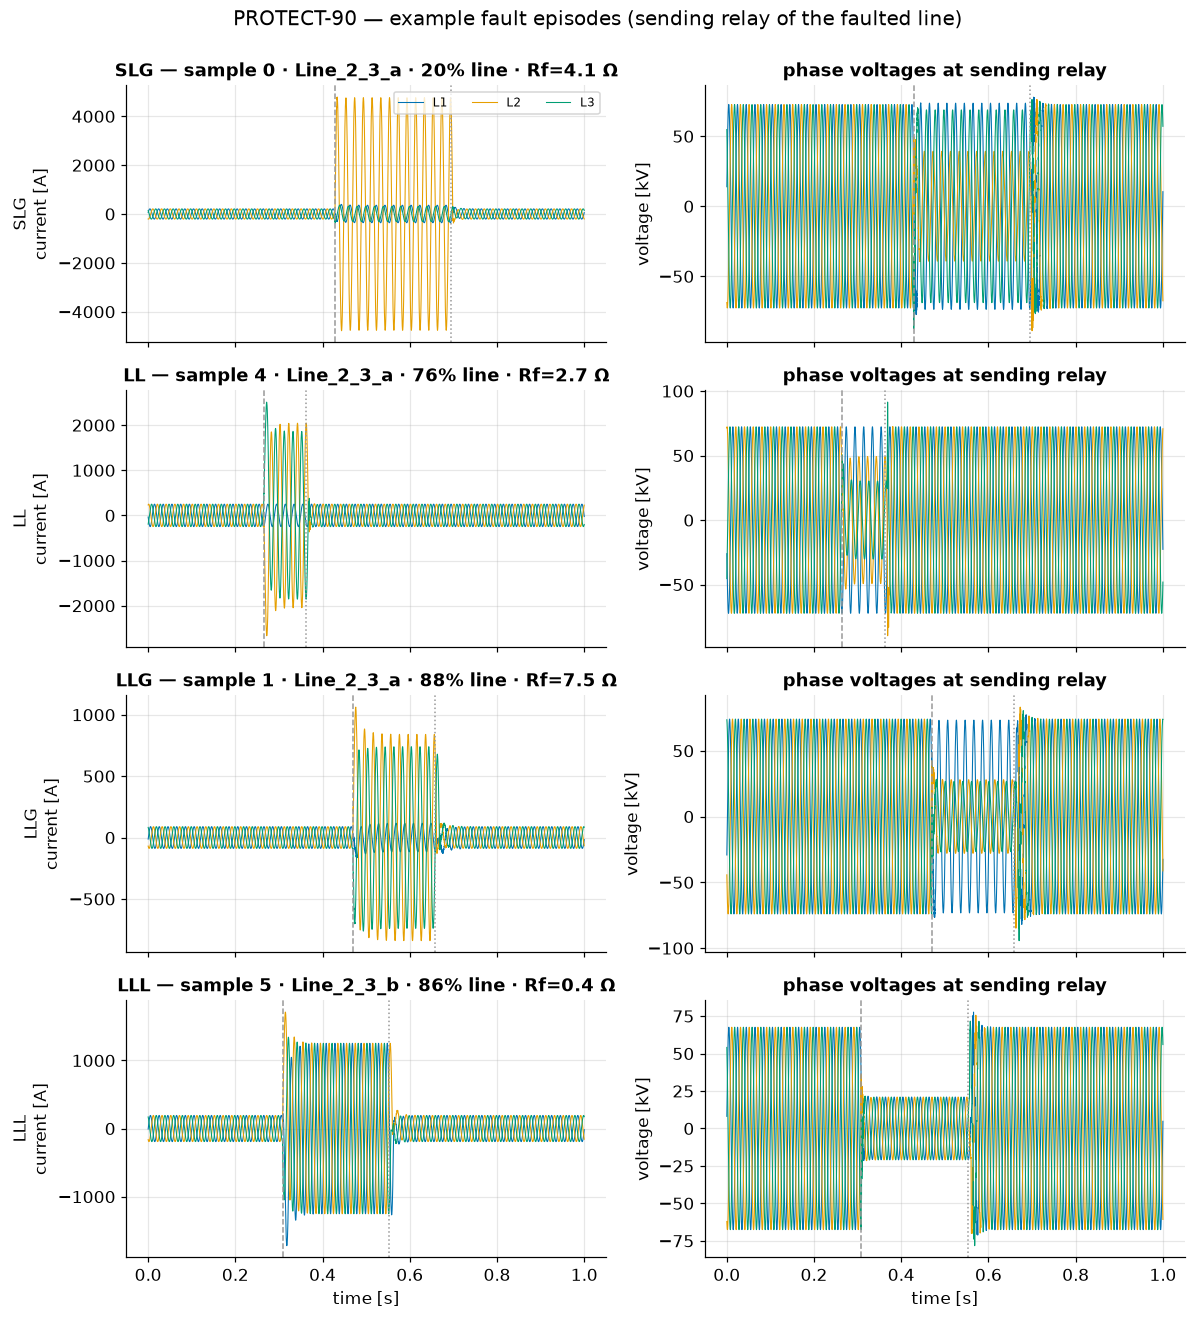

In [5]:
def relay_channels(line_name, terminal="S"):
    # Current and voltage channel names (L1,L2,L3) at one terminal of a line section.
    _, f, t, sfx = line_name.split("_")
    bus = min(int(f), int(t)) if terminal == "S" else max(int(f), int(t))
    sub = chan[(chan.line == line_name) & (chan.bus == bus)].sort_values("phase")
    cur = sub[sub.quantity == "current"]["channel"].tolist()
    vol = sub[sub.quantity == "voltage"]["channel"].tolist()
    return cur, vol

# One representative episode per category (lowest sample_id of each sc_type).
EXAMPLES = [(2, 0), (1, 4), (3, 1), (0, 5)]  # (sc_type, sample_id): SLG, LL, LLG, LLL

fig, axes = plt.subplots(len(EXAMPLES), 2, figsize=(11, 12), sharex=True)
for i, (sct, sid) in enumerate(EXAMPLES):
    r = meta.loc[meta.sample_id == sid].iloc[0]
    ep = load_episode(sid)
    t = ep["time_s"].values
    cur, vol = relay_channels(r.fault_target, "S")
    for ph, cc in zip(["L1", "L2", "L3"], cur):
        axes[i, 0].plot(t, ep[cc].values, color=PHASE_COLORS[ph], lw=0.7, label=ph)
    for ph, vc in zip(["L1", "L2", "L3"], vol):
        axes[i, 1].plot(t, ep[vc].values / 1e3, color=PHASE_COLORS[ph], lw=0.7, label=ph)
    for j in (0, 1):
        axes[i, j].axvline(r.t_evnt_start, color=GREY, ls="--", lw=1)
        axes[i, j].axvline(r.t_evnt_end, color=GREY, ls=":", lw=1)
    axes[i, 0].set_ylabel(f"{SC_TYPE[sct]}\ncurrent [A]")
    axes[i, 1].set_ylabel("voltage [kV]")
    axes[i, 0].set_title(f"{SC_TYPE[sct]} — sample {sid} · {r.fault_target} · "
                         f"{r.sc_location:.0f}% line · Rf={r.fault_resistance:.1f} Ω")
    axes[i, 1].set_title("phase voltages at sending relay")
axes[0, 0].legend(loc="upper right", ncol=3, fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time [s]")
fig.suptitle("PROTECT-90 — example fault episodes (sending relay of the faulted line)",
             y=0.997, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "example_waveforms.png")
fig.savefig(FIG_DIR / "example_waveforms.svg")
plt.show()

## 5. Class balance

Fault categories are close to balanced (~2,250 episodes each). The faulted **line section** is *not*
uniform: the `_a` circuits are faulted far more often than the `_b` circuits, because the parallel
`_b` lines are randomly switched out of service in some scenarios and cannot then host a fault.

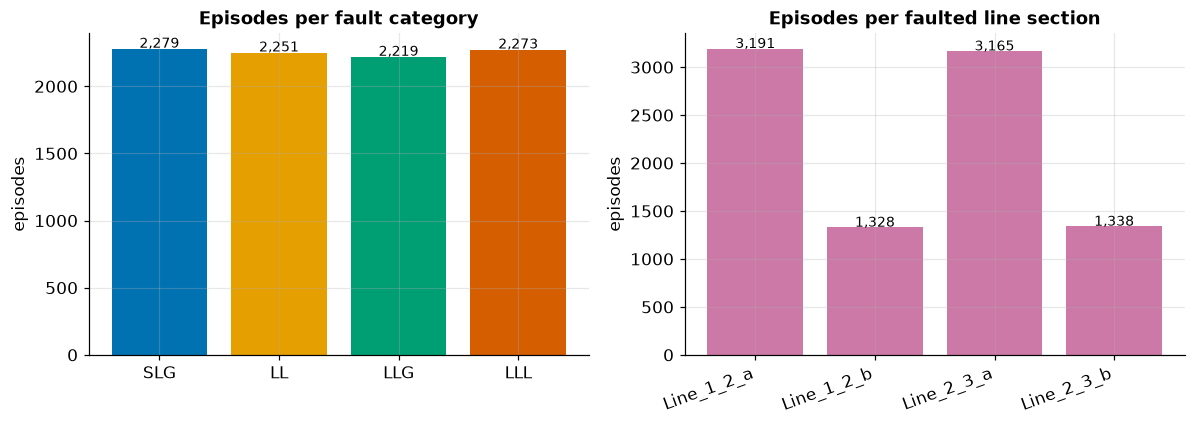

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

vc = meta["fault_type"].value_counts().reindex(["SLG", "LL", "LLG", "LLL"])
ax[0].bar(vc.index, vc.values, color=[BLUE, ORANGE, GREEN, RED])
for i, v in enumerate(vc.values):
    ax[0].text(i, v + 8, f"{v:,}", ha="center", fontsize=9)
ax[0].set(title="Episodes per fault category", ylabel="episodes")

lc = meta["fault_target"].value_counts().reindex(
    ["Line_1_2_a", "Line_1_2_b", "Line_2_3_a", "Line_2_3_b"])
ax[1].bar(range(len(lc)), lc.values, color=PURPLE)
ax[1].set_xticks(range(len(lc)))
ax[1].set_xticklabels(lc.index, rotation=20, ha="right")
for i, v in enumerate(lc.values):
    ax[1].text(i, v + 8, f"{v:,}", ha="center", fontsize=9)
ax[1].set(title="Episodes per faulted line section", ylabel="episodes")

fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png")
fig.savefig(FIG_DIR / "class_balance.svg")
plt.show()

## 6. Domain-randomisation coverage

Fault **location**, **resistance**, and **inception time** are each sampled roughly uniformly across
their ranges — location across the full 0–100 % of the line, resistance across ~0.1–10 Ω, and inception
across 0.2–0.5 s (after the pre-fault window has settled). This broad, even coverage is what makes the
dataset suitable for robustness and domain-shift studies.

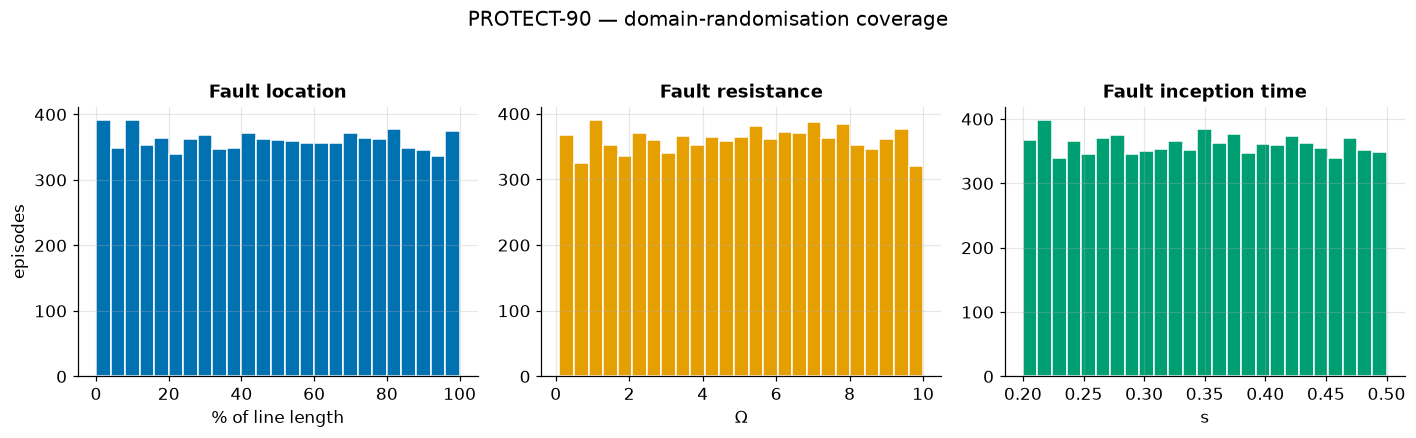

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].hist(meta["sc_location"], bins=25, color=BLUE, edgecolor="white")
ax[0].set(title="Fault location", xlabel="% of line length", ylabel="episodes")
ax[1].hist(meta["fault_resistance"], bins=25, color=ORANGE, edgecolor="white")
ax[1].set(title="Fault resistance", xlabel="Ω")
ax[2].hist(meta["t_evnt_start"], bins=25, color=GREEN, edgecolor="white")
ax[2].set(title="Fault inception time", xlabel="s")
fig.suptitle("PROTECT-90 — domain-randomisation coverage", y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "scenario_coverage.png")
fig.savefig(FIG_DIR / "scenario_coverage.svg")
plt.show()

## 7. Citation & license

PROTECT-90 has **two distinct citable artifacts** — cite the one(s) you rely on.

**1. The dataset** (Zenodo) — if you use the waveforms/metadata:

```bibtex
@dataset{kordowich2026protect90,
  author    = {Kordowich, Georg and Oelhaf, Julian and Bergler, Christian and
               Maier, Andreas and J{\"a}ger, Johann and Bayer, Siming},
  title     = {{PROTECT-90: A Fault Dataset for Power System Protection}},
  year      = {2026},
  publisher = {Zenodo},
  version   = {1.0.0},
  doi       = {10.5281/zenodo.21109169},
  url       = {https://doi.org/10.5281/zenodo.21109169},
  note      = {Concept DOI (all versions): 10.5281/zenodo.18418329}
}
```

**2. The paper** (IEEE PES ISGT Europe 2026, accepted; preprint [arXiv:2606.24298](https://arxiv.org/abs/2606.24298)) — when referring to the design:

```bibtex
@inproceedings{oelhaf2026protect90,
  author        = {Oelhaf, Julian and Kordowich, Georg and Bergler, Christian and
                   Maier, Andreas and J{\"a}ger, Johann and Bayer, Siming},
  title         = {{PROTECT-90: A Fault Dataset for Power System Protection}},
  booktitle     = {2026 IEEE PES Innovative Smart Grid Technologies Europe (ISGT EUROPE)},
  address       = {Budapest, Hungary},
  year          = {2026},
  eprint        = {2606.24298},
  archivePrefix = {arXiv},
  note          = {Accepted; final pages and IEEE DOI to appear}
}
```

**Acknowledgment:** the PROTECT-90 dataset was **created and generated by Georg Kordowich** (Institute
of Electrical Energy Systems, FAU), who designed and ran the DIgSILENT PowerFactory EMT simulation and
domain-randomization pipeline producing all 9,022 episodes. Funded by the DFG — 535389056.

**Licenses:** the dataset (Zenodo) is **CC BY 4.0**; the code/notebook/figures in the companion
repository are **MIT**. Contacts: Julian Oelhaf (julian.oelhaf@fau.de), Georg Kordowich
(georg.kordowich@fau.de) — FAU Erlangen-Nürnberg (PRL, EES) and OTH Amberg-Weiden.